### Dry Bean Dataset — 7 clases
Rubén Pérez Y Marcos Del Saz

---
Este notebook implementa y sintoniza una Red Neuronal Multicapa (MLP) para clasificar
7 tipos de granos del *Dry Bean Dataset* (UCI). Cubre:
- Carga, exploración y preprocesamiento de datos
- Arquitecturas mínimas y profundas
- Ajuste de Epochs, Learning Rate, Batch Size y Optimizadores
- Tabla comparativa global y debate final


---
##  PARTE 1 — Carga y Preparación de Datos

In [1]:
# ── Instalación de dependencias (ejecutar sólo en Colab) ──────────────────────
# !pip install ucimlrepo tensorflow --quiet

import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from ucimlrepo import fetch_ucirepo

# Configuración de estilo visual
sns.set_theme(style="whitegrid", palette="Set2")
plt.rcParams['figure.dpi'] = 110

# ── 1. Descarga del dataset desde UCI ─────────────────────────────────────────
dry_bean = fetch_ucirepo(id=602)

X_raw = dry_bean.data.features   # Variables predictoras (16 columnas)
y_raw = dry_bean.data.targets     # Variable objetivo (Class)

# Unimos en un único DataFrame para exploración
df = pd.concat([X_raw, y_raw], axis=1)

print("=" * 55)
print(f"  Filas    : {df.shape[0]:,}")
print(f"  Columnas : {df.shape[1]}")
print(f"  Target   : 'Class' — {df['Class'].nunique()} clases únicas")
print("=" * 55)
df.head()


  Filas    : 13,611
  Columnas : 17
  Target   : 'Class' — 7 clases únicas


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4,Class
0,28395,610.291,208.178117,173.888747,1.197191,0.549812,28715,190.141097,0.763923,0.988856,0.958027,0.913358,0.007332,0.003147,0.834222,0.998724,SEKER
1,28734,638.018,200.524796,182.734419,1.097356,0.411785,29172,191.272751,0.783968,0.984986,0.887034,0.953861,0.006979,0.003564,0.909851,0.998430,SEKER
2,29380,624.110,212.826130,175.931143,1.209713,0.562727,29690,193.410904,0.778113,0.989559,0.947849,0.908774,0.007244,0.003048,0.825871,0.999066,SEKER
3,30008,645.884,210.557999,182.516516,1.153638,0.498616,30724,195.467062,0.782681,0.976696,0.903936,0.928329,0.007017,0.003215,0.861794,0.994199,SEKER
4,30140,620.134,201.847882,190.279279,1.060798,0.333680,30417,195.896503,0.773098,0.990893,0.984877,0.970516,0.006697,0.003665,0.941900,0.999166,SEKER


In [2]:
# ── 2. Tipos de datos y estadísticas básicas ──────────────────────────────────
print("Tipos de datos:")
print(df.dtypes)
print()
print("Estadísticas descriptivas:")
df.describe()


Tipos de datos:
Area                 int64
Perimeter          float64
MajorAxisLength    float64
MinorAxisLength    float64
AspectRatio        float64
Eccentricity       float64
ConvexArea           int64
EquivDiameter      float64
Extent             float64
Solidity           float64
Roundness          float64
Compactness        float64
ShapeFactor1       float64
ShapeFactor2       float64
ShapeFactor3       float64
ShapeFactor4       float64
Class               object
dtype: object

Estadísticas descriptivas:


,Area,Perimeter,MajorAxisLength,MinorAxisLength,AspectRatio,Eccentricity,ConvexArea,EquivDiameter,Extent,Solidity,Roundness,Compactness,ShapeFactor1,ShapeFactor2,ShapeFactor3,ShapeFactor4
count,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000,13611.000000
mean,53048.284549,855.283459,320.141867,202.270714,1.583242,0.750895,53768.200206,253.064220,0.749733,0.987143,0.873282,0.799864,0.006564,0.001716,0.643590,0.995063
std,29324.095717,214.289696,85.694186,44.970091,0.246678,0.092002,29774.915817,59.177120,0.049086,0.004660,0.059520,0.061713,0.001128,0.000596,0.098996,0.004366
min,20420.000000,524.736000,183.601165,122.512653,1.024868,0.218951,20684.000000,161.243764,0.555315,0.919246,0.489618,0.640577,0.002778,0.000564,0.410339,0.947687
25%,36328.000000,703.523500,253.303633,175.848170,1.432307,0.715928,36714.500000,215.068003,0.718634,0.985670,0.832096,0.762469,0.005900,0.001154,0.581359,0.993703
50%,44652.000000,794.941000,296.883367,192.431733,1.551124,0.764441,45178.000000,238.438026,0.759859,0.988283,0.883157,0.801277,0.006645,0.001694,0.642044,0.996386
75%,61332.000000,977.213000,376.495012,217.031741,1.707109,0.810466,62294.000000,279.446467,0.786851,0.990013,0.916869,0.834270,0.007271,0.002170,0.696006,0.997883
max,254616.000000,1985.370000,738.860154,460.198497,2.430306,0.911423,263261.000000,569.374358,0.866195,0.994677,0.990685,0.987303,0.010451,0.003665,0.974767,0.999733


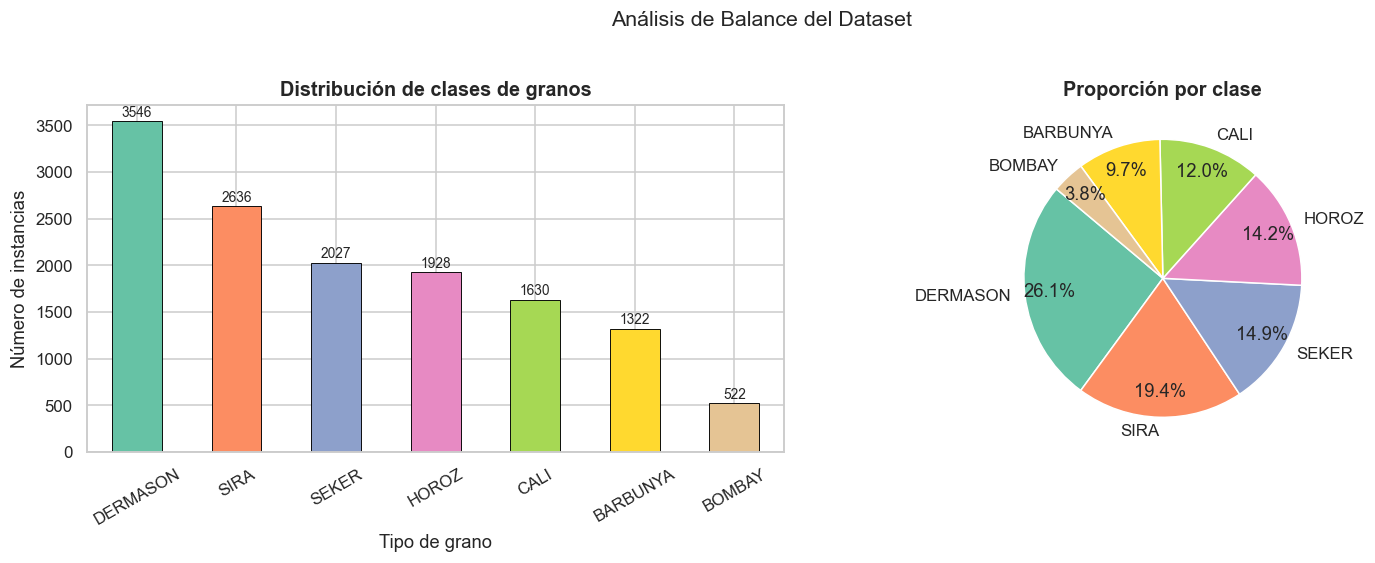


Conteo por clase:
Class
DERMASON    3546
SIRA        2636
SEKER       2027
HOROZ       1928
CALI        1630
BARBUNYA    1322
BOMBAY       522
Name: count, dtype: int64


In [3]:
# ── 3. Distribución de clases (balanceo) ──────────────────────────────────────
class_counts = df['Class'].value_counts().sort_values(ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

# Barplot de conteo
class_counts.plot(kind='bar', ax=axes[0], color=sns.color_palette("Set2", 7),
                  edgecolor='black', linewidth=0.6)
axes[0].set_title("Distribución de clases de granos", fontsize=13, fontweight='bold')
axes[0].set_xlabel("Tipo de grano")
axes[0].set_ylabel("Número de instancias")
axes[0].tick_params(axis='x', rotation=30)
for bar, count in zip(axes[0].patches, class_counts.values):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 50,
                 str(count), ha='center', fontsize=9)

# Pie chart
axes[1].pie(class_counts.values, labels=class_counts.index,
            autopct='%1.1f%%', colors=sns.color_palette("Set2", 7),
            startangle=140, pctdistance=0.82)
axes[1].set_title("Proporción por clase", fontsize=13, fontweight='bold')

plt.suptitle("Análisis de Balance del Dataset", fontsize=14, y=1.02)
plt.tight_layout()
plt.savefig("distribucion_clases.png", bbox_inches='tight')
plt.show()

print("\nConteo por clase:")
print(class_counts)


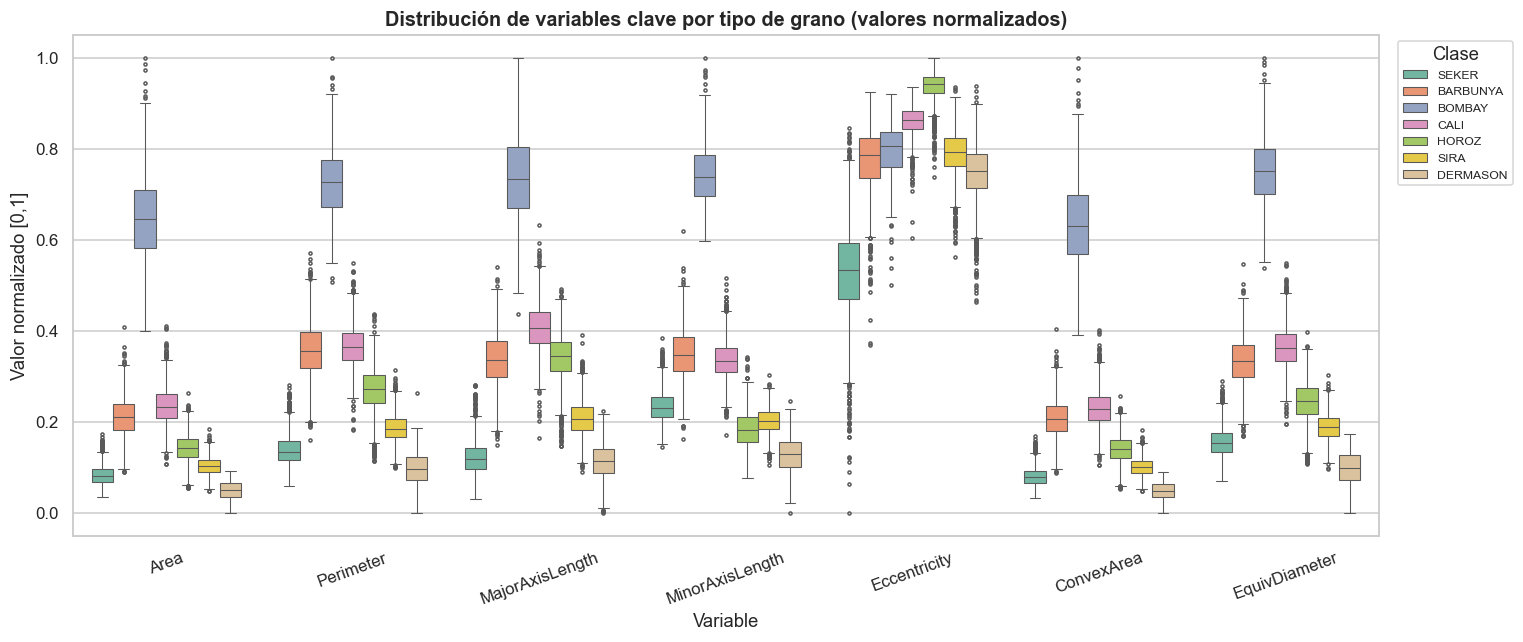

In [4]:
# ── 4. Gráfica descriptiva: Boxplots de las principales variables ──────────────
# Normalizamos para poder comparar en la misma escala
from sklearn.preprocessing import MinMaxScaler

features_to_plot = ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength',
                    'Eccentricity', 'ConvexArea', 'EquivDiameter']
df_plot = df[features_to_plot + ['Class']].copy()

# Normalización sólo para visualización
scaler_vis = MinMaxScaler()
df_plot[features_to_plot] = scaler_vis.fit_transform(df_plot[features_to_plot])
df_melted = df_plot.melt(id_vars='Class', var_name='Feature', value_name='Valor')

plt.figure(figsize=(14, 6))
sns.boxplot(data=df_melted, x='Feature', y='Valor', hue='Class',
            palette="Set2", linewidth=0.7, fliersize=2)
plt.title("Distribución de variables clave por tipo de grano (valores normalizados)",
          fontsize=13, fontweight='bold')
plt.xlabel("Variable")
plt.ylabel("Valor normalizado [0,1]")
plt.xticks(rotation=20)
plt.legend(title='Clase', bbox_to_anchor=(1.01, 1), loc='upper left', fontsize=8)
plt.tight_layout()
plt.savefig("boxplots_variables.png", bbox_inches='tight')
plt.show()


---
## 🔧 PARTE 2 — Preprocesamiento

Variables NUMÉRICAS (16):  ['Area', 'Perimeter', 'MajorAxisLength', 'MinorAxisLength', 'AspectRatio', 'Eccentricity', 'ConvexArea', 'EquivDiameter', 'Extent', 'Solidity', 'Roundness', 'Compactness', 'ShapeFactor1', 'ShapeFactor2', 'ShapeFactor3', 'ShapeFactor4']
Variables CATEGÓRICAS (1): ['Class']


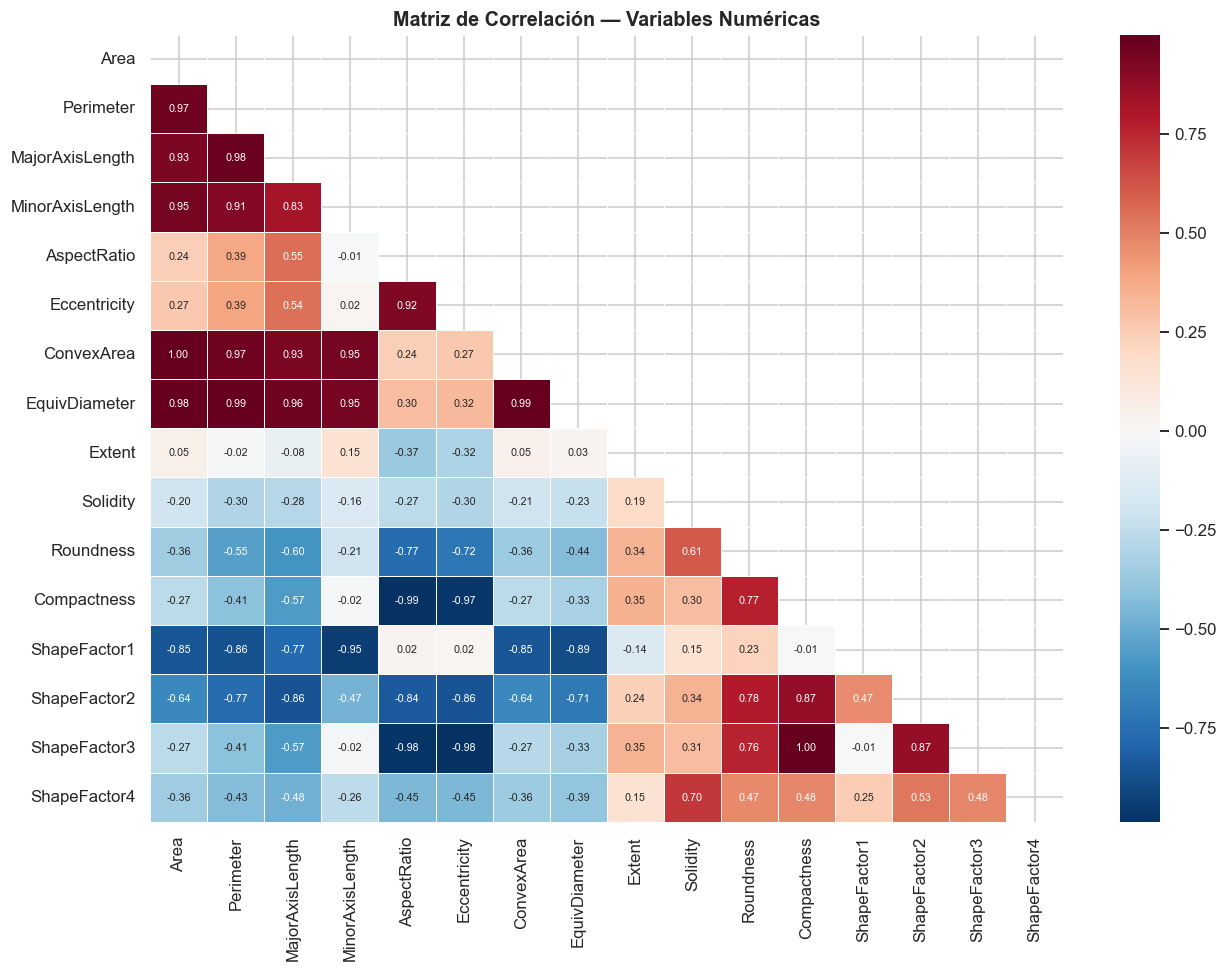

In [5]:
# ── 2.1 Exploración de variables ──────────────────────────────────────────────
numericas  = df.select_dtypes(include=['float64','int64']).columns.tolist()
categoricas = df.select_dtypes(include=['object']).columns.tolist()

print(f"Variables NUMÉRICAS ({len(numericas)}):  {numericas}")
print(f"Variables CATEGÓRICAS ({len(categoricas)}): {categoricas}")

# Correlación entre variables numéricas
plt.figure(figsize=(12, 9))
corr = df[numericas].corr()
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, cmap='RdBu_r', center=0, annot=True,
            fmt='.2f', linewidths=0.4, annot_kws={"size": 7})
plt.title("Matriz de Correlación — Variables Numéricas", fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig("correlacion.png", bbox_inches='tight')
plt.show()


In [6]:
# ── 2.1 Valores nulos ─────────────────────────────────────────────────────────
nulos = df.isnull().sum()
print("Valores nulos por columna:")
print(nulos[nulos > 0] if nulos.sum() > 0 else "✅ No hay valores nulos en el dataset.")
print(f"\nTotal nulos: {nulos.sum()}")


Valores nulos por columna:
✅ No hay valores nulos en el dataset.

Total nulos: 0


In [7]:
# ── 2.3 Codificación y normalización ─────────────────────────────────────────
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder

# Separar características y etiqueta
X = df.drop(columns=['Class'])
y = df['Class']

# Codificar la variable objetivo como enteros (0-6)
le = LabelEncoder()
y_encoded = le.fit_transform(y)

print("Clases codificadas:")
for i, cls in enumerate(le.classes_):
    print(f"  {i} → {cls}")

# División train / test (80% / 20%, estratificada)
X_train, X_test, y_train, y_test = train_test_split(
    X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
)

# Normalización con StandardScaler
# fit_transform SÓLO en train → transform en test para evitar data leakage
scaler = StandardScaler()
X_train_sc = scaler.fit_transform(X_train)
X_test_sc  = scaler.transform(X_test)

print(f"\nTrain: {X_train_sc.shape}  |  Test: {X_test_sc.shape}")
print(f"Clases en train: {np.bincount(y_train)}")


Clases codificadas:
  0 → BARBUNYA
  1 → BOMBAY
  2 → CALI
  3 → DERMASON
  4 → HOROZ
  5 → SEKER
  6 → SIRA

Train: (10888, 16)  |  Test: (2723, 16)
Clases en train: [1057  418 1304 2837 1542 1621 2109]


In [8]:
# ── One-hot encoding para CategoricalCrossentropy ─────────────────────────────
import tensorflow as tf
from tensorflow.keras.utils import to_categorical

NUM_CLASSES = 7
y_train_ohe = to_categorical(y_train, NUM_CLASSES)
y_test_ohe  = to_categorical(y_test,  NUM_CLASSES)

print(f"y_train_ohe shape: {y_train_ohe.shape}")
print(f"y_test_ohe  shape: {y_test_ohe.shape}")


y_train_ohe shape: (10888, 7)
y_test_ohe  shape: (2723, 7)


---
## 🧠 PARTE 3 — Entrenamiento y Ajuste de la Red Neuronal

### Función de utilidad para evaluación

In [9]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense
from tensorflow.keras.optimizers import Adam, SGD
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay,
                             precision_score, recall_score, f1_score)

# Diccionario global para almacenar resultados de todos los experimentos
RESULTADOS = {}

def nombre_keras_seguro(nombre):
    """Convierte un nombre legible en un identificador v?lido para Keras."""
    txt = str(nombre)
    txt = txt.replace('?', '-').replace('?', '-')
    txt = ''.join(ch if (ch.isalnum() or ch in '._/>-') else '_' for ch in txt)
    if not txt or not (txt[0].isalnum() or txt[0] == '.'):
        txt = f"M_{txt}"
    return txt

def evaluar_modelo(model, X_tr, y_tr, X_te, y_te, nombre="Modelo"):
    """
    Entrena y evalúa un modelo Keras.
    Devuelve dict con métricas y guarda en RESULTADOS global.
    """
    history = model.fit(X_tr, y_tr,
                        validation_data=(X_te, y_te),
                        verbose=0)
    
    # Predicciones (clase con mayor probabilidad)
    y_pred_tr = np.argmax(model.predict(X_tr, verbose=0), axis=1)
    y_pred_te = np.argmax(model.predict(X_te, verbose=0), axis=1)
    y_tr_int  = np.argmax(y_tr, axis=1)
    y_te_int  = np.argmax(y_te, axis=1)

    acc_tr  = accuracy_score(y_tr_int, y_pred_tr)
    acc_te  = accuracy_score(y_te_int, y_pred_te)
    rec_te  = recall_score(y_te_int, y_pred_te, average='weighted')
    f1_te   = f1_score(y_te_int, y_pred_te, average='weighted')
    prec_te = precision_score(y_te_int, y_pred_te, average='weighted')

    print(f"\n{'='*55}")
    print(f"  {nombre}")
    print(f"{'='*55}")
    print(f"  Accuracy  Train : {acc_tr:.4f}")
    print(f"  Accuracy  Test  : {acc_te:.4f}")
    print(f"  Precision Test  : {prec_te:.4f}")
    print(f"  Recall    Test  : {rec_te:.4f}")
    print(f"  F1-Score  Test  : {f1_te:.4f}")
    print()
    print(classification_report(y_te_int, y_pred_te,
                                target_names=le.classes_, digits=3))

    # Matriz de confusión
    cm = confusion_matrix(y_te_int, y_pred_te)
    fig, ax = plt.subplots(figsize=(8, 6))
    disp = ConfusionMatrixDisplay(cm, display_labels=le.classes_)
    disp.plot(ax=ax, colorbar=True, cmap='Blues', xticks_rotation=35)
    ax.set_title(f"Matriz de Confusión — {nombre}", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"cm_{nombre.replace(' ','_')}.png", bbox_inches='tight')
    plt.show()

    RESULTADOS[nombre] = {
        'acc_train': acc_tr, 'acc_test': acc_te,
        'recall': rec_te,    'f1': f1_te
    }
    return history

def plot_history(histories, labels, title="Curvas de Aprendizaje"):
    """Grafica loss y accuracy de train/val para varias historias."""
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    colores = plt.cm.Set2(np.linspace(0, 1, len(histories)))
    
    for hist, label, color in zip(histories, labels, colores):
        axes[0].plot(hist.history['loss'],         color=color, label=f'{label} train')
        axes[0].plot(hist.history['val_loss'], '--', color=color, label=f'{label} val')
        axes[1].plot(hist.history['accuracy'],         color=color, label=f'{label} train')
        axes[1].plot(hist.history['val_accuracy'], '--', color=color, label=f'{label} val')

    axes[0].set_title("Loss"); axes[0].set_xlabel("Epoch"); axes[0].legend(fontsize=7)
    axes[1].set_title("Accuracy"); axes[1].set_xlabel("Epoch"); axes[1].legend(fontsize=7)
    fig.suptitle(title, fontsize=13, fontweight='bold')
    plt.tight_layout()
    plt.savefig(f"curves_{title.replace(' ','_')}.png", bbox_inches='tight')
    plt.show()


---
### 3.1 Red Neuronal Minimalista (sin capas ocultas)

Model: "Minimalista"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 7)              │           119 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 119 (476.00 B)

 Trainable params: 119 (476.00 B)

 Non-trainable params: 0 (0.00 B)


  3.1 Minimalista
  Accuracy  Train : 0.9236
  Accuracy  Test  : 0.9196
  Precision Test  : 0.9205
  Recall    Test  : 0.9196
  F1-Score  Test  : 0.9198

              precision    recall  f1-score   support

    BARBUNYA      0.952     0.891     0.920       265
      BOMBAY      1.000     1.000     1.000       104
        CALI      0.933     0.942     0.937       326
    DERMASON      0.923     0.900     0.911       709
       HOROZ      0.963     0.953     0.958       386
       SEKER      0.928     0.953     0.940       406
        SIRA      0.841     0.880     0.860       527

    accuracy                          0.920      2723
   macro avg      0.934     0.931     0.933      2723
weighted avg      0.921     0.920     0.920      2723



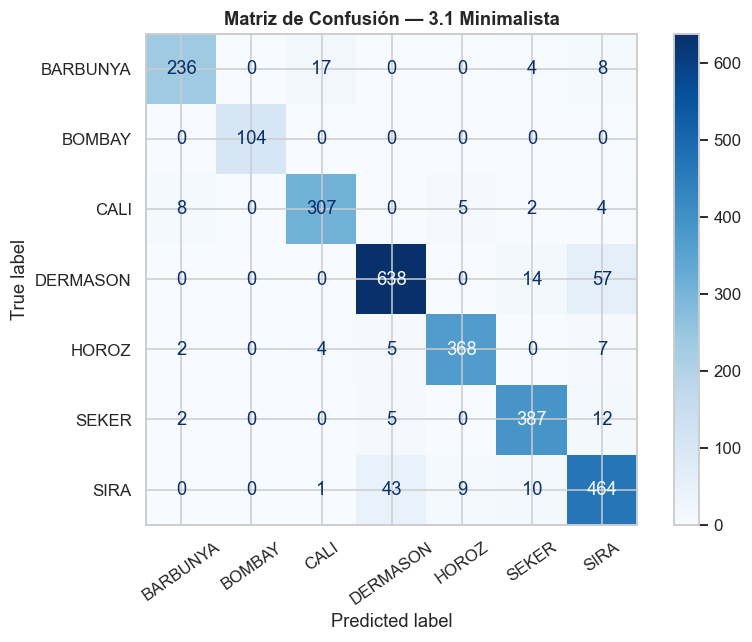

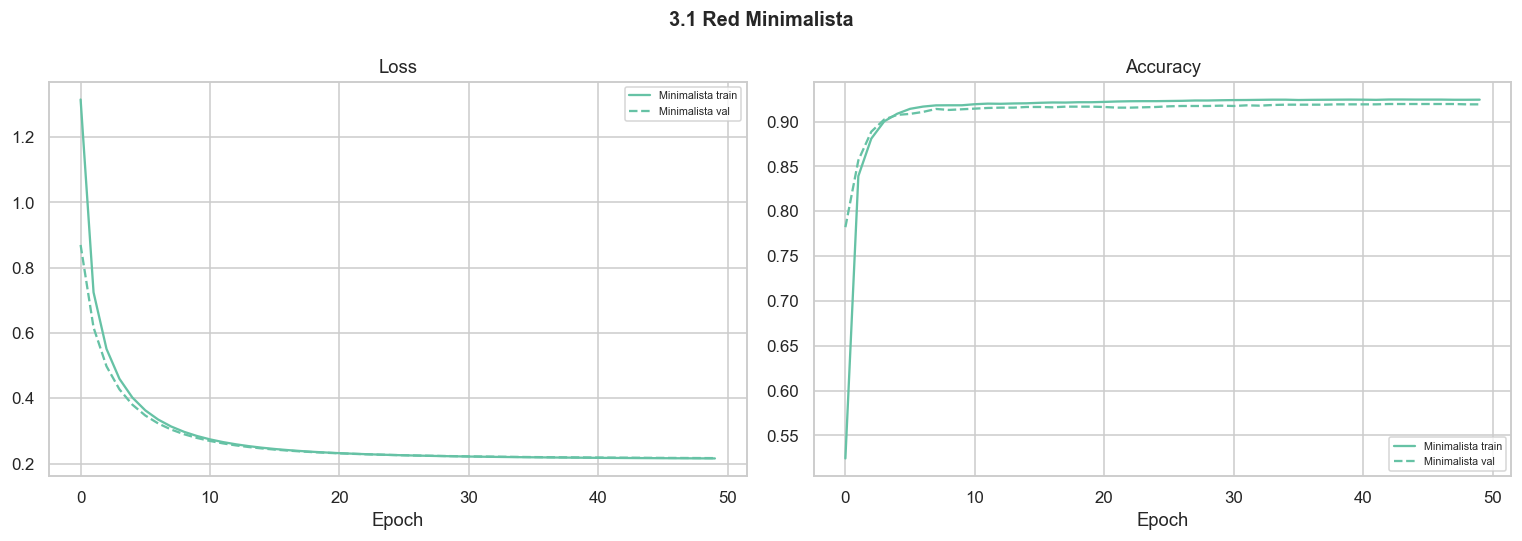

In [10]:
tf.random.set_seed(42)

# ── Red LINEAL: sólo capa de salida, sin capas ocultas ────────────────────────
modelo_min = Sequential([
    Dense(7, activation='softmax', input_shape=(X_train_sc.shape[1],))
], name="Minimalista")

modelo_min.compile(
    optimizer=Adam(learning_rate=0.001),
    loss='categorical_crossentropy',
    metrics=['accuracy']
)
modelo_min.summary()

hist_min = modelo_min.fit(
    X_train_sc, y_train_ohe,
    epochs=50,
    batch_size=32,
    validation_data=(X_test_sc, y_test_ohe),
    verbose=0
)

hist_min_eval = evaluar_modelo(
    modelo_min, X_train_sc, y_train_ohe,
    X_test_sc, y_test_ohe, nombre="3.1 Minimalista"
)
plot_history([hist_min], ["Minimalista"], title="3.1 Red Minimalista")


---
### 3.2 Impacto de la Profundidad



  3.2a — Dense(16)
  Accuracy  Train : 0.9330
  Accuracy  Test  : 0.9258
  Precision Test  : 0.9262
  Recall    Test  : 0.9258
  F1-Score  Test  : 0.9259

              precision    recall  f1-score   support

    BARBUNYA      0.941     0.898     0.919       265
      BOMBAY      1.000     1.000     1.000       104
        CALI      0.936     0.942     0.939       326
    DERMASON      0.928     0.915     0.922       709
       HOROZ      0.963     0.951     0.957       386
       SEKER      0.933     0.963     0.948       406
        SIRA      0.863     0.882     0.872       527

    accuracy                          0.926      2723
   macro avg      0.938     0.936     0.937      2723
weighted avg      0.926     0.926     0.926      2723



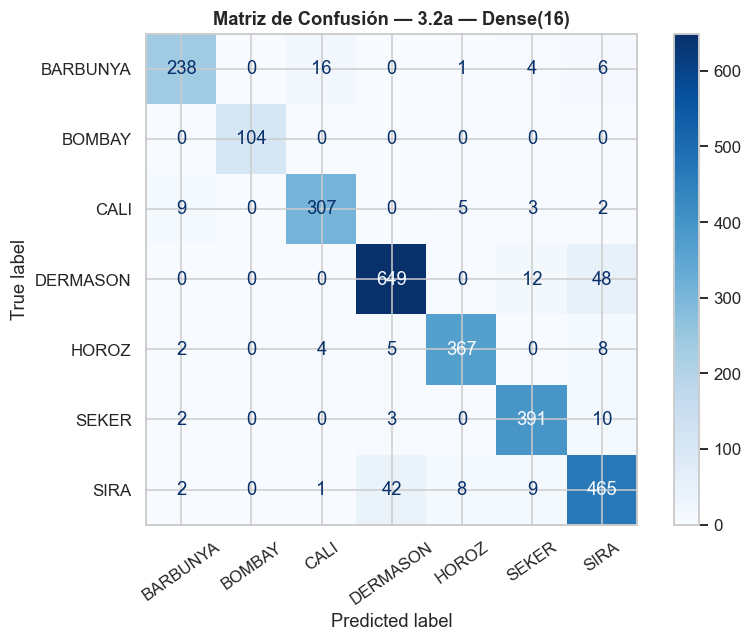


  3.2b — Dense(64-32)
  Accuracy  Train : 0.9429
  Accuracy  Test  : 0.9266
  Precision Test  : 0.9265
  Recall    Test  : 0.9266
  F1-Score  Test  : 0.9264

              precision    recall  f1-score   support

    BARBUNYA      0.937     0.898     0.917       265
      BOMBAY      1.000     1.000     1.000       104
        CALI      0.942     0.942     0.942       326
    DERMASON      0.916     0.921     0.918       709
       HOROZ      0.961     0.961     0.961       386
       SEKER      0.931     0.963     0.947       406
        SIRA      0.883     0.871     0.877       527

    accuracy                          0.927      2723
   macro avg      0.938     0.937     0.937      2723
weighted avg      0.926     0.927     0.926      2723



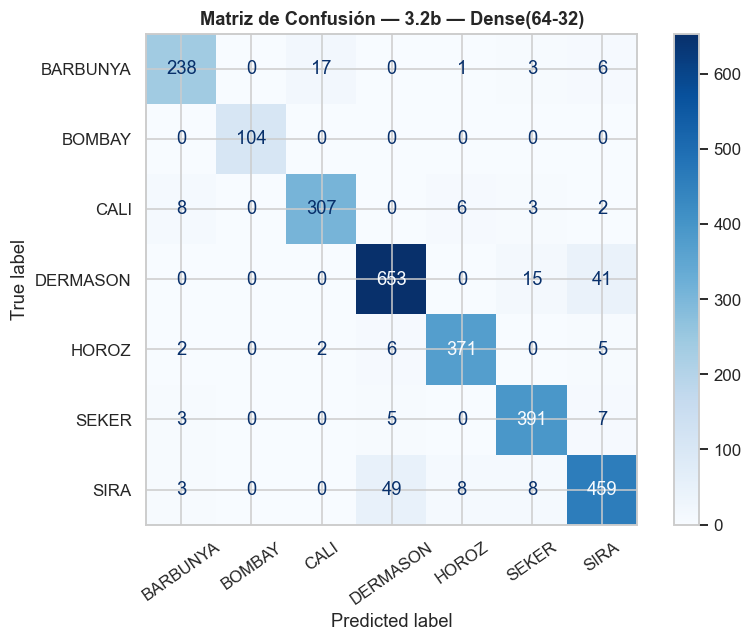


  3.2c — Dense(128-64-32)
  Accuracy  Train : 0.9467
  Accuracy  Test  : 0.9225
  Precision Test  : 0.9230
  Recall    Test  : 0.9225
  F1-Score  Test  : 0.9225

              precision    recall  f1-score   support

    BARBUNYA      0.955     0.875     0.913       265
      BOMBAY      1.000     0.990     0.995       104
        CALI      0.934     0.948     0.941       326
    DERMASON      0.921     0.915     0.918       709
       HOROZ      0.954     0.959     0.956       386
       SEKER      0.935     0.953     0.944       406
        SIRA      0.857     0.877     0.867       527

    accuracy                          0.923      2723
   macro avg      0.936     0.931     0.933      2723
weighted avg      0.923     0.923     0.923      2723



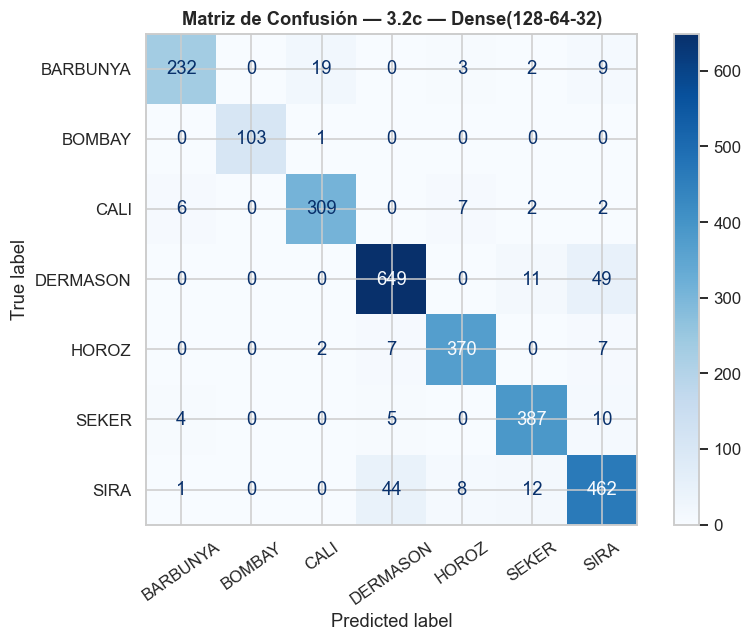

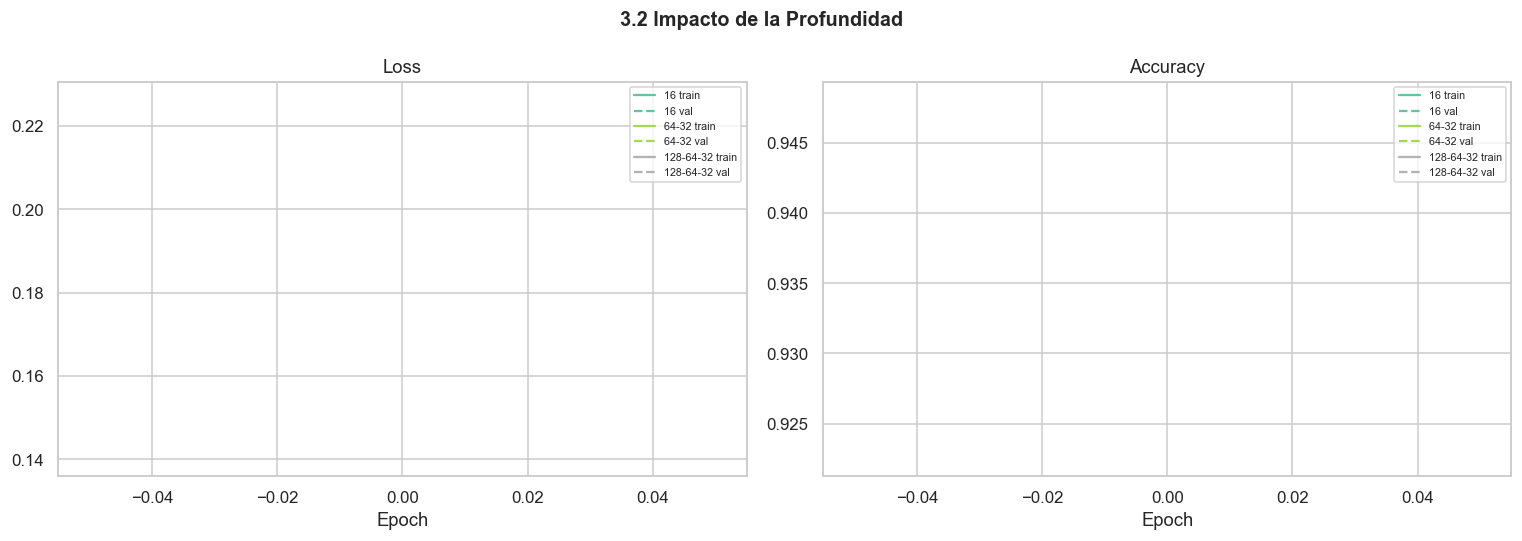

In [11]:
tf.random.set_seed(42)

EPOCHS_DEPTH = 50
BATCH_DEPTH  = 32
LR_DEPTH     = 0.001

def construir_y_evaluar(capas_config, nombre):
    """Construye un Sequential con la lista de capas dada, lo evalúa y devuelve historia."""
    tf.keras.backend.clear_session()
    m = Sequential(capas_config)
    m.compile(optimizer=Adam(learning_rate=LR_DEPTH),
              loss='categorical_crossentropy', metrics=['accuracy'])
    m.fit(X_train_sc, y_train_ohe,
          epochs=EPOCHS_DEPTH, batch_size=BATCH_DEPTH,
          validation_data=(X_test_sc, y_test_ohe), verbose=0)
    return evaluar_modelo(m, X_train_sc, y_train_ohe,
                          X_test_sc, y_test_ohe, nombre=nombre), m

# ── 3.2a: 1 capa oculta — 16 neuronas ────────────────────────────────────────
capas_a = [
    Dense(16, activation='relu', input_shape=(X_train_sc.shape[1],)),
    Dense(7,  activation='softmax')
]
hist_a, m_a = construir_y_evaluar(capas_a, "3.2a — Dense(16)")

# ── 3.2b: 2 capas ocultas — 64-32 ────────────────────────────────────────────
capas_b = [
    Dense(64, activation='relu', input_shape=(X_train_sc.shape[1],)),
    Dense(32, activation='relu'),
    Dense(7,  activation='softmax')
]
hist_b, m_b = construir_y_evaluar(capas_b, "3.2b — Dense(64-32)")

# ── 3.2c: 3 capas ocultas — 128-64-32 ────────────────────────────────────────
capas_c = [
    Dense(128, activation='relu', input_shape=(X_train_sc.shape[1],)),
    Dense(64,  activation='relu'),
    Dense(32,  activation='relu'),
    Dense(7,   activation='softmax')
]
hist_c, m_c = construir_y_evaluar(capas_c, "3.2c — Dense(128-64-32)")

plot_history([hist_a, hist_b, hist_c],
             ["16", "64-32", "128-64-32"],
             title="3.2 Impacto de la Profundidad")


---
### Arquitectura fija para apartados 3.3 – 3.6

```
Input (16 features)
  → Dense(32, relu)
  → Dense(16, relu)
  → Dense(7, softmax)
```


In [12]:
def modelo_fijo(optimizer=None, nombre="Modelo"):
    """
    Devuelve el modelo fijo de la práctica:
      Dense(32, relu) → Dense(16, relu) → Dense(7, softmax)
    Si optimizer=None se usa Adam(0.001) por defecto.
    """
    if optimizer is None:
        optimizer = Adam(learning_rate=0.001)
    m = Sequential([
        Dense(32, activation='relu', input_shape=(X_train_sc.shape[1],)),
        Dense(16, activation='relu'),
        Dense(7,  activation='softmax')
    ])
    m.compile(optimizer=optimizer,
              loss='categorical_crossentropy',
              metrics=['accuracy'])
    return m


---
### 3.3 Efecto de los Epochs


  3.3 — 10 epochs
  Accuracy  Train : 0.9314
  Accuracy  Test  : 0.9251
  Precision Test  : 0.9253
  Recall    Test  : 0.9251
  F1-Score  Test  : 0.9251

              precision    recall  f1-score   support

    BARBUNYA      0.937     0.898     0.917       265
      BOMBAY      1.000     0.990     0.995       104
        CALI      0.939     0.942     0.940       326
    DERMASON      0.920     0.914     0.917       709
       HOROZ      0.966     0.964     0.965       386
       SEKER      0.933     0.958     0.945       406
        SIRA      0.867     0.877     0.872       527

    accuracy                          0.925      2723
   macro avg      0.937     0.935     0.936      2723
weighted avg      0.925     0.925     0.925      2723



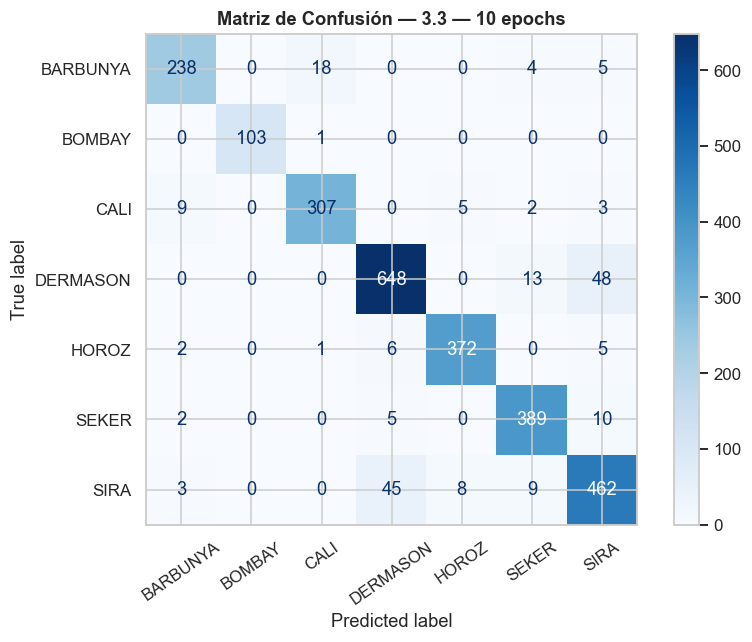


  3.3 — 50 epochs
  Accuracy  Train : 0.9378
  Accuracy  Test  : 0.9269
  Precision Test  : 0.9269
  Recall    Test  : 0.9269
  F1-Score  Test  : 0.9268

              precision    recall  f1-score   support

    BARBUNYA      0.937     0.894     0.915       265
      BOMBAY      1.000     1.000     1.000       104
        CALI      0.933     0.939     0.936       326
    DERMASON      0.923     0.918     0.921       709
       HOROZ      0.961     0.961     0.961       386
       SEKER      0.936     0.970     0.953       406
        SIRA      0.876     0.875     0.876       527

    accuracy                          0.927      2723
   macro avg      0.938     0.937     0.937      2723
weighted avg      0.927     0.927     0.927      2723



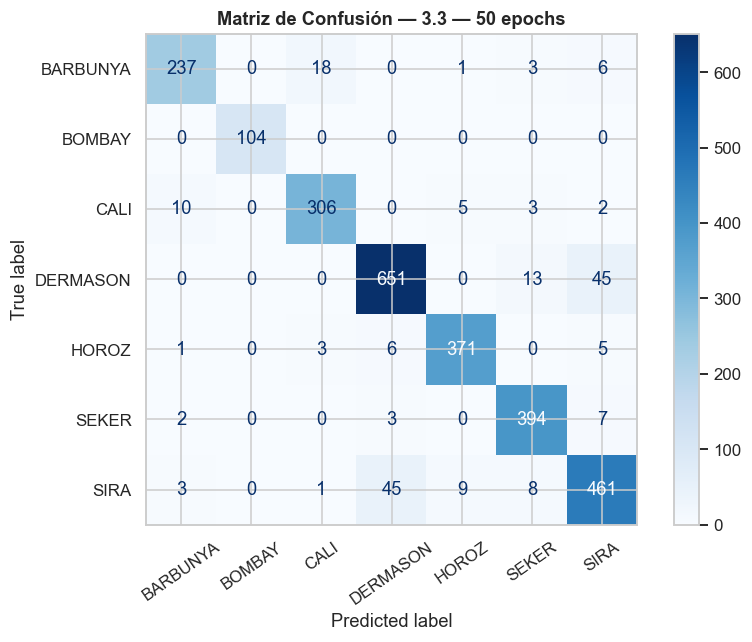


  3.3 — 150 epochs
  Accuracy  Train : 0.9428
  Accuracy  Test  : 0.9288
  Precision Test  : 0.9287
  Recall    Test  : 0.9288
  F1-Score  Test  : 0.9286

              precision    recall  f1-score   support

    BARBUNYA      0.940     0.894     0.917       265
      BOMBAY      1.000     1.000     1.000       104
        CALI      0.939     0.951     0.945       326
    DERMASON      0.913     0.935     0.924       709
       HOROZ      0.961     0.956     0.958       386
       SEKER      0.940     0.958     0.949       406
        SIRA      0.891     0.867     0.879       527

    accuracy                          0.929      2723
   macro avg      0.941     0.937     0.939      2723
weighted avg      0.929     0.929     0.929      2723



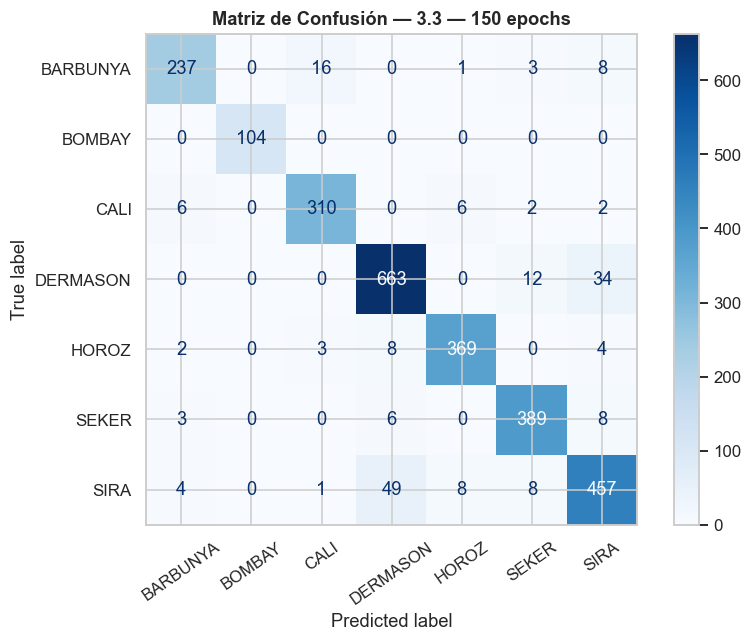

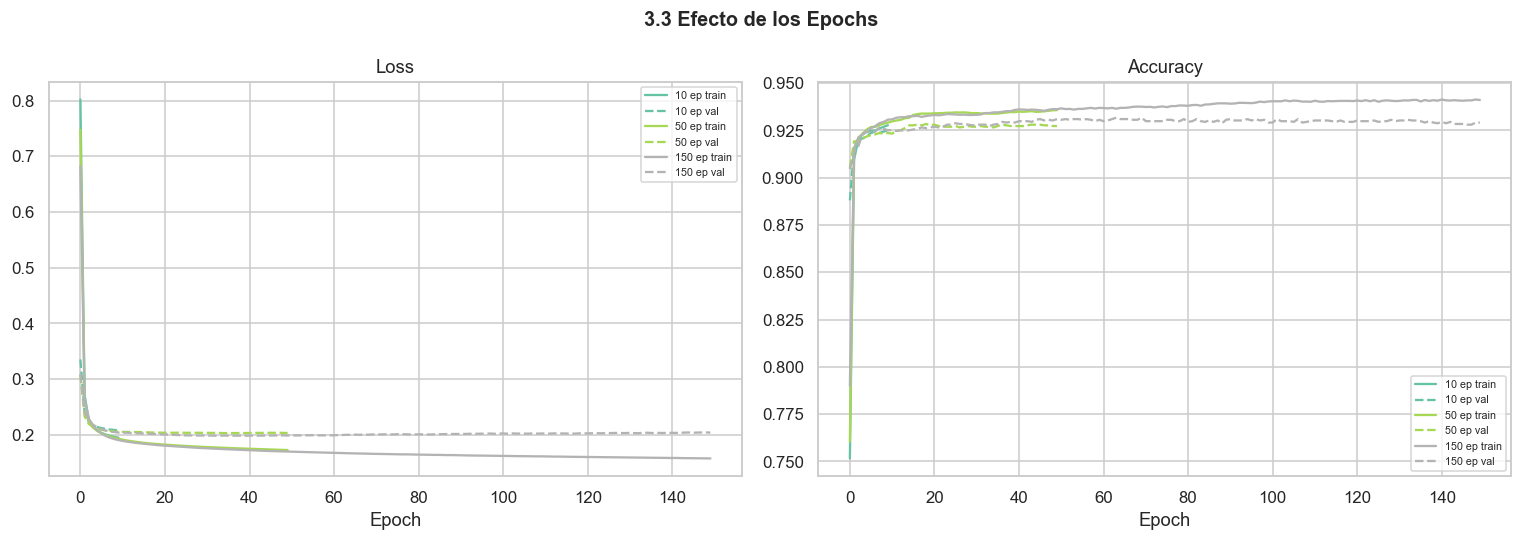

In [13]:
tf.random.set_seed(42)
histories_epochs = {}

for n_epochs, nombre in [(10, "3.3 — 10 epochs"),
                          (50, "3.3 — 50 epochs"),
                          (150,"3.3 — 150 epochs")]:
    m = modelo_fijo(nombre=nombre)
    h = m.fit(X_train_sc, y_train_ohe,
              epochs=n_epochs, batch_size=32,
              validation_data=(X_test_sc, y_test_ohe), verbose=0)
    evaluar_modelo(m, X_train_sc, y_train_ohe,
                   X_test_sc, y_test_ohe, nombre=nombre)
    histories_epochs[nombre] = h

plot_history(list(histories_epochs.values()),
             ["10 ep", "50 ep", "150 ep"],
             title="3.3 Efecto de los Epochs")


---
### 3.4 Learning Rate


  3.4 — LR=0.1
  Accuracy  Train : 0.6787
  Accuracy  Test  : 0.6746
  Precision Test  : 0.5833
  Recall    Test  : 0.6746
  F1-Score  Test  : 0.6091

              precision    recall  f1-score   support

    BARBUNYA      0.000     0.000     0.000       265
      BOMBAY      0.000     0.000     0.000       104
        CALI      0.000     0.000     0.000       326
    DERMASON      0.888     0.927     0.907       709
       HOROZ      0.341     0.938     0.500       386
       SEKER      0.941     0.943     0.942       406
        SIRA      0.845     0.825     0.835       527

    accuracy                          0.675      2723
   macro avg      0.431     0.519     0.455      2723
weighted avg      0.583     0.675     0.609      2723



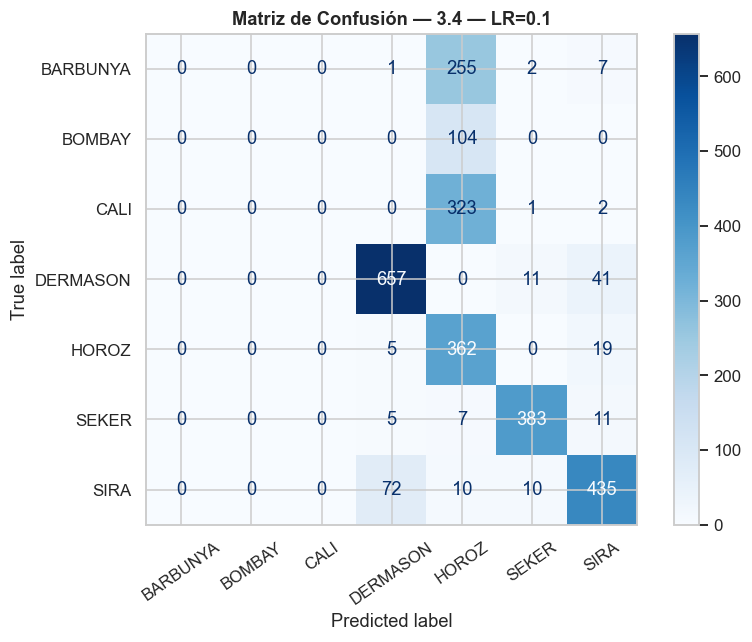


  3.4 — LR=0.001
  Accuracy  Train : 0.9388
  Accuracy  Test  : 0.9273
  Precision Test  : 0.9274
  Recall    Test  : 0.9273
  F1-Score  Test  : 0.9273

              precision    recall  f1-score   support

    BARBUNYA      0.934     0.902     0.917       265
      BOMBAY      1.000     1.000     1.000       104
        CALI      0.936     0.939     0.937       326
    DERMASON      0.923     0.918     0.921       709
       HOROZ      0.961     0.961     0.961       386
       SEKER      0.944     0.961     0.952       406
        SIRA      0.872     0.880     0.876       527

    accuracy                          0.927      2723
   macro avg      0.939     0.937     0.938      2723
weighted avg      0.927     0.927     0.927      2723



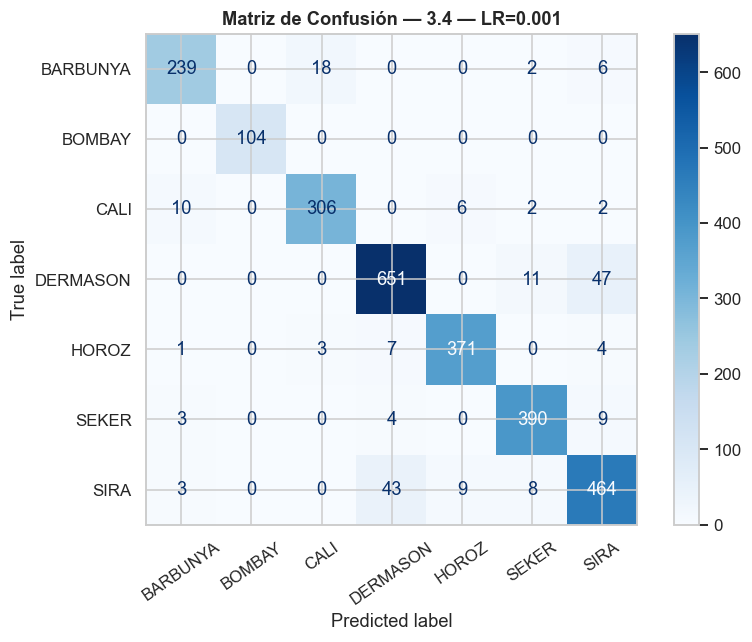


  3.4 — LR=0.00001
  Accuracy  Train : 0.7785
  Accuracy  Test  : 0.7775
  Precision Test  : 0.8200
  Recall    Test  : 0.7775
  F1-Score  Test  : 0.7204

              precision    recall  f1-score   support

    BARBUNYA      0.920     0.872     0.895       265
      BOMBAY      0.943     0.962     0.952       104
        CALI      0.884     0.936     0.909       326
    DERMASON      0.632     0.980     0.769       709
       HOROZ      0.818     0.917     0.864       386
       SEKER      0.880     0.961     0.919       406
        SIRA      0.913     0.080     0.147       527

    accuracy                          0.777      2723
   macro avg      0.856     0.815     0.779      2723
weighted avg      0.820     0.777     0.720      2723



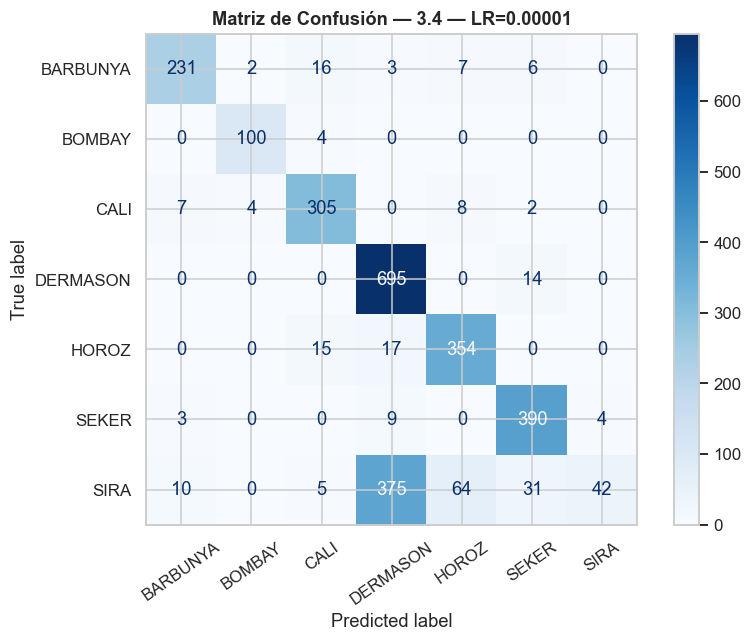

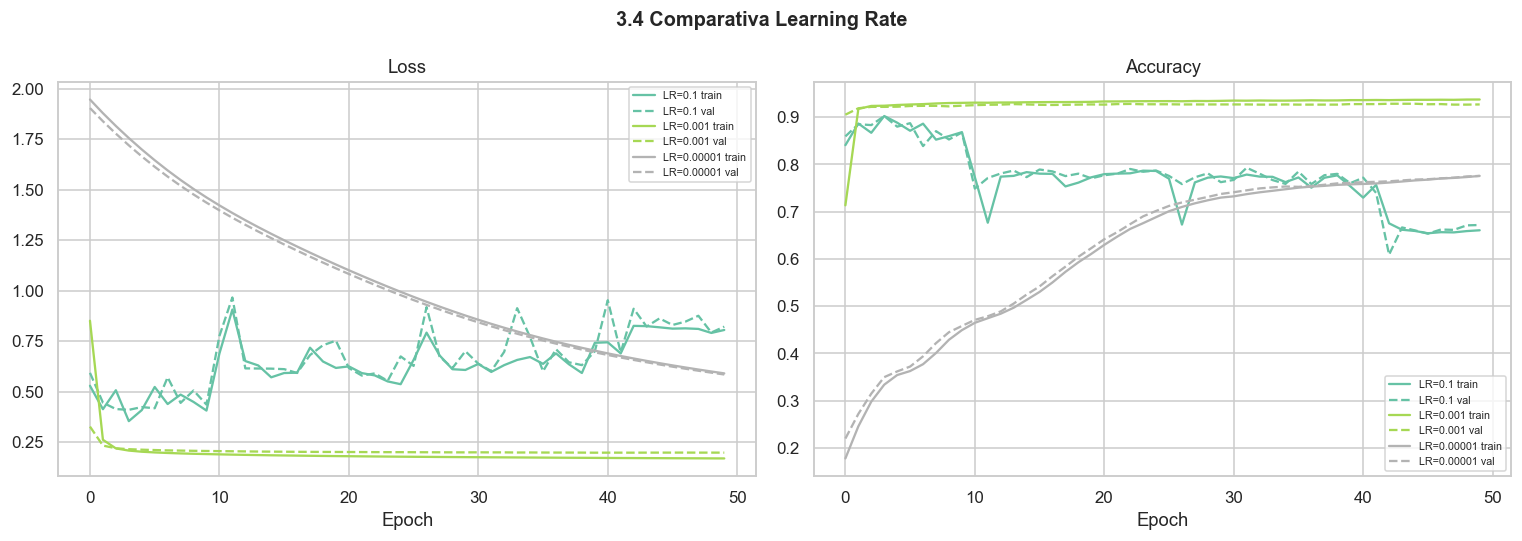

In [14]:
tf.random.set_seed(42)
histories_lr = {}

for lr, nombre in [(0.1,     "3.4 — LR=0.1"),
                   (0.001,   "3.4 — LR=0.001"),
                   (0.00001, "3.4 — LR=0.00001")]:
    m = modelo_fijo(optimizer=Adam(learning_rate=lr), nombre=nombre)
    h = m.fit(X_train_sc, y_train_ohe,
              epochs=50, batch_size=32,
              validation_data=(X_test_sc, y_test_ohe), verbose=0)
    evaluar_modelo(m, X_train_sc, y_train_ohe,
                   X_test_sc, y_test_ohe, nombre=nombre)
    histories_lr[nombre] = h

plot_history(list(histories_lr.values()),
             ["LR=0.1", "LR=0.001", "LR=0.00001"],
             title="3.4 Comparativa Learning Rate")


---
### 3.5 Variación del Batch Size

  3.5 — Batch=8: 164.5 s

  3.5 — Batch=8
  Accuracy  Train : 0.9405
  Accuracy  Test  : 0.9251
  Precision Test  : 0.9252
  Recall    Test  : 0.9251
  F1-Score  Test  : 0.9251

              precision    recall  f1-score   support

    BARBUNYA      0.941     0.902     0.921       265
      BOMBAY      1.000     1.000     1.000       104
        CALI      0.933     0.945     0.939       326
    DERMASON      0.915     0.917     0.916       709
       HOROZ      0.966     0.951     0.958       386
       SEKER      0.935     0.961     0.948       406
        SIRA      0.873     0.875     0.874       527

    accuracy                          0.925      2723
   macro avg      0.938     0.936     0.937      2723
weighted avg      0.925     0.925     0.925      2723



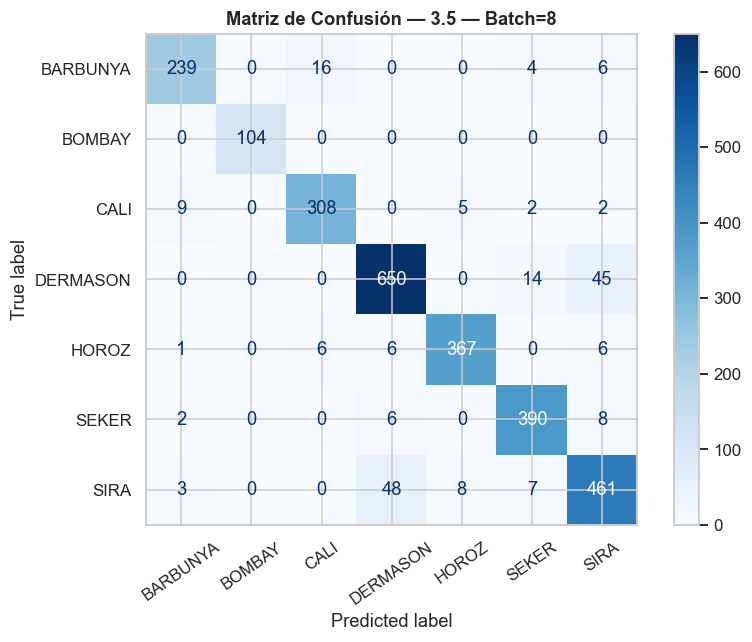

  3.5 — Batch=32: 40.0 s

  3.5 — Batch=32
  Accuracy  Train : 0.9389
  Accuracy  Test  : 0.9254
  Precision Test  : 0.9253
  Recall    Test  : 0.9254
  F1-Score  Test  : 0.9253

              precision    recall  f1-score   support

    BARBUNYA      0.934     0.906     0.920       265
      BOMBAY      1.000     1.000     1.000       104
        CALI      0.939     0.939     0.939       326
    DERMASON      0.915     0.922     0.919       709
       HOROZ      0.958     0.956     0.957       386
       SEKER      0.938     0.968     0.953       406
        SIRA      0.878     0.861     0.870       527

    accuracy                          0.925      2723
   macro avg      0.937     0.936     0.937      2723
weighted avg      0.925     0.925     0.925      2723



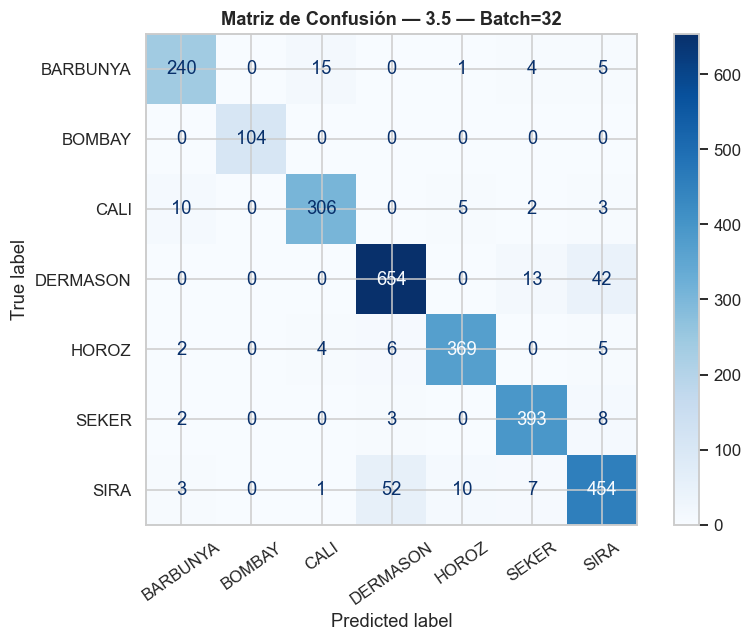

  3.5 — Batch=512: 8.9 s

  3.5 — Batch=512
  Accuracy  Train : 0.9296
  Accuracy  Test  : 0.9221
  Precision Test  : 0.9228
  Recall    Test  : 0.9221
  F1-Score  Test  : 0.9222

              precision    recall  f1-score   support

    BARBUNYA      0.951     0.883     0.916       265
      BOMBAY      1.000     0.990     0.995       104
        CALI      0.925     0.951     0.938       326
    DERMASON      0.930     0.901     0.915       709
       HOROZ      0.964     0.959     0.961       386
       SEKER      0.920     0.966     0.942       406
        SIRA      0.854     0.879     0.866       527

    accuracy                          0.922      2723
   macro avg      0.935     0.933     0.933      2723
weighted avg      0.923     0.922     0.922      2723



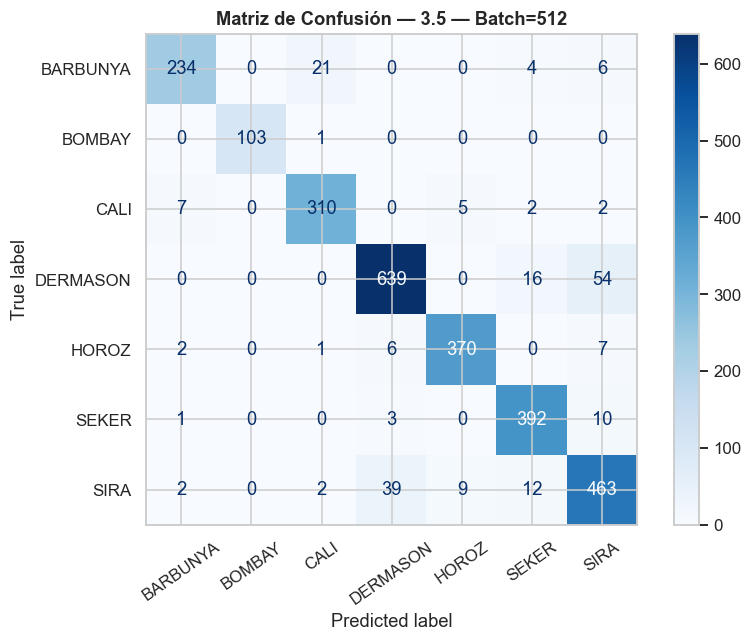

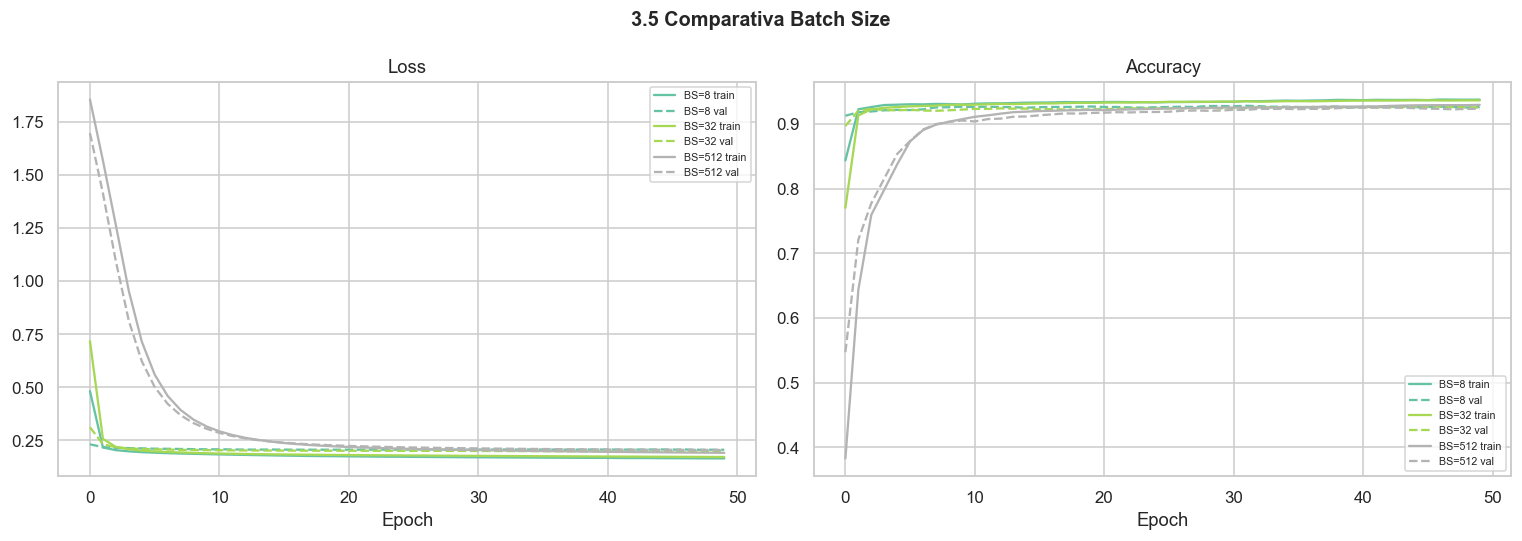

In [15]:
import time
tf.random.set_seed(42)
histories_bs = {}

for bs, nombre in [(8,   "3.5 — Batch=8"),
                   (32,  "3.5 — Batch=32"),
                   (512, "3.5 — Batch=512")]:
    m = modelo_fijo(nombre=nombre)
    t0 = time.time()
    h = m.fit(X_train_sc, y_train_ohe,
              epochs=50, batch_size=bs,
              validation_data=(X_test_sc, y_test_ohe), verbose=0)
    elapsed = time.time() - t0
    print(f"  {nombre}: {elapsed:.1f} s")
    evaluar_modelo(m, X_train_sc, y_train_ohe,
                   X_test_sc, y_test_ohe, nombre=nombre)
    histories_bs[nombre] = h

plot_history(list(histories_bs.values()),
             ["BS=8", "BS=32", "BS=512"],
             title="3.5 Comparativa Batch Size")


---
### 3.6 Comparativa Optimizadores: Adam vs SGD


  3.6 — Adam
  Accuracy  Train : 0.9386
  Accuracy  Test  : 0.9269
  Precision Test  : 0.9269
  Recall    Test  : 0.9269
  F1-Score  Test  : 0.9268

              precision    recall  f1-score   support

    BARBUNYA      0.944     0.891     0.917       265
      BOMBAY      1.000     1.000     1.000       104
        CALI      0.934     0.948     0.941       326
    DERMASON      0.919     0.922     0.920       709
       HOROZ      0.958     0.956     0.957       386
       SEKER      0.938     0.966     0.951       406
        SIRA      0.880     0.873     0.876       527

    accuracy                          0.927      2723
   macro avg      0.939     0.936     0.937      2723
weighted avg      0.927     0.927     0.927      2723



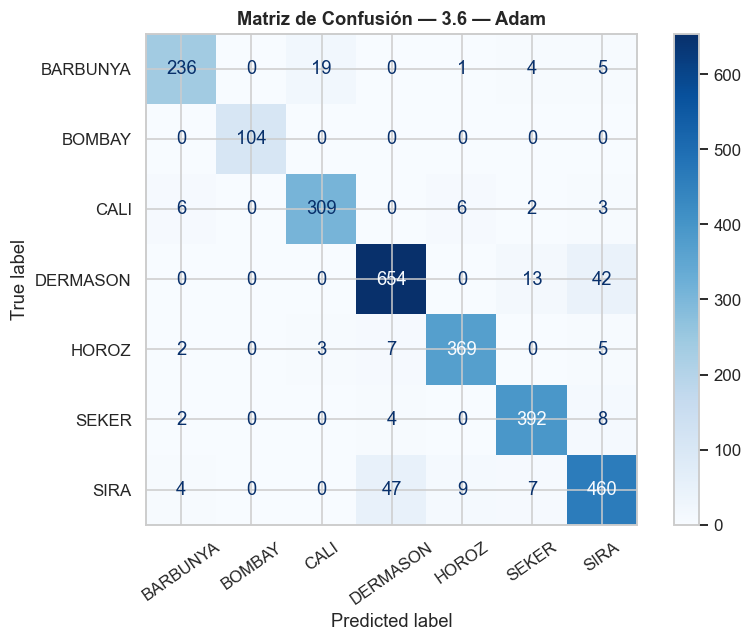


  3.6 — SGD
  Accuracy  Train : 0.9319
  Accuracy  Test  : 0.9251
  Precision Test  : 0.9254
  Recall    Test  : 0.9251
  F1-Score  Test  : 0.9251

              precision    recall  f1-score   support

    BARBUNYA      0.944     0.894     0.919       265
      BOMBAY      1.000     1.000     1.000       104
        CALI      0.936     0.945     0.940       326
    DERMASON      0.925     0.915     0.920       709
       HOROZ      0.961     0.951     0.956       386
       SEKER      0.935     0.963     0.949       406
        SIRA      0.862     0.879     0.870       527

    accuracy                          0.925      2723
   macro avg      0.938     0.935     0.936      2723
weighted avg      0.925     0.925     0.925      2723



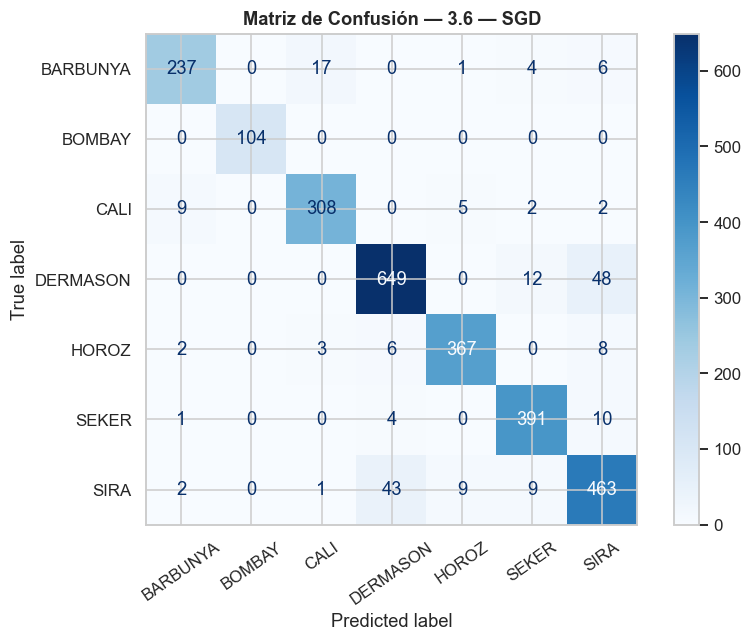

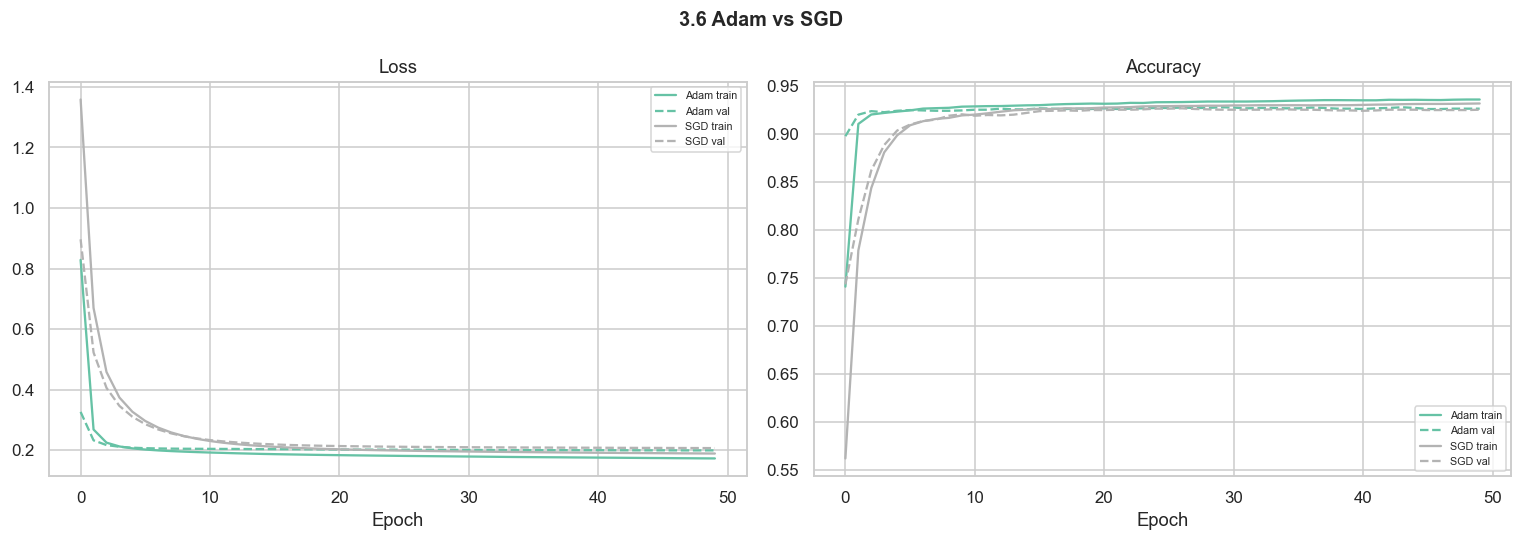

In [16]:
tf.random.set_seed(42)
histories_opt = {}

# Adam — LR 0.001
m_adam = modelo_fijo(optimizer=Adam(learning_rate=0.001), nombre="3.6 — Adam")
h_adam = m_adam.fit(X_train_sc, y_train_ohe,
                    epochs=50, batch_size=32,
                    validation_data=(X_test_sc, y_test_ohe), verbose=0)
evaluar_modelo(m_adam, X_train_sc, y_train_ohe,
               X_test_sc, y_test_ohe, nombre="3.6 — Adam")
histories_opt["Adam"] = h_adam

# SGD — LR 0.01 (más alto que Adam para compensar la ausencia de momento adaptativo)
m_sgd = modelo_fijo(optimizer=SGD(learning_rate=0.01), nombre="3.6 — SGD")
h_sgd = m_sgd.fit(X_train_sc, y_train_ohe,
                   epochs=50, batch_size=32,
                   validation_data=(X_test_sc, y_test_ohe), verbose=0)
evaluar_modelo(m_sgd, X_train_sc, y_train_ohe,
               X_test_sc, y_test_ohe, nombre="3.6 — SGD")
histories_opt["SGD"] = h_sgd

plot_history([h_adam, h_sgd], ["Adam", "SGD"], title="3.6 Adam vs SGD")


---
## 📊 PARTE 4 — Tabla Comparativa Global

In [17]:
# ── Construcción de la tabla con los resultados acumulados ────────────────────
orden_filas = [
    "3.1 Minimalista",
    "3.2a — Dense(16)",
    "3.2b — Dense(64-32)",
    "3.2c — Dense(128-64-32)",
    "3.3 — 10 epochs",
    "3.3 — 50 epochs",
    "3.3 — 150 epochs",
    "3.4 — LR=0.1",
    "3.4 — LR=0.001",
    "3.4 — LR=0.00001",
    "3.5 — Batch=8",
    "3.5 — Batch=32",
    "3.5 — Batch=512",
    "3.6 — Adam",
    "3.6 — SGD",
]

filas = []
for key in orden_filas:
    if key in RESULTADOS:
        r = RESULTADOS[key]
        filas.append({
            "Modelo":            key,
            "Accuracy (Train)":  f"{r['acc_train']:.4f}",
            "Accuracy (Test)":   f"{r['acc_test']:.4f}",
            "Recall":            f"{r['recall']:.4f}",
            "F1-Score":          f"{r['f1']:.4f}",
        })

tabla = pd.DataFrame(filas)
print(tabla.to_markdown(index=False))
tabla


| Modelo                  |   Accuracy (Train) |   Accuracy (Test) |   Recall |   F1-Score |
|:------------------------|-------------------:|------------------:|---------:|-----------:|
| 3.1 Minimalista         |             0.9236 |            0.9196 |   0.9196 |     0.9198 |
| 3.2a — Dense(16)        |             0.933  |            0.9258 |   0.9258 |     0.9259 |
| 3.2b — Dense(64-32)     |             0.9429 |            0.9266 |   0.9266 |     0.9264 |
| 3.2c — Dense(128-64-32) |             0.9467 |            0.9225 |   0.9225 |     0.9225 |
| 3.3 — 10 epochs         |             0.9314 |            0.9251 |   0.9251 |     0.9251 |
| 3.3 — 50 epochs         |             0.9378 |            0.9269 |   0.9269 |     0.9268 |
| 3.3 — 150 epochs        |             0.9428 |            0.9288 |   0.9288 |     0.9286 |
| 3.4 — LR=0.1            |             0.6787 |            0.6746 |   0.6746 |     0.6091 |
| 3.4 — LR=0.001          |             0.9388 |            0.9273 |  

,Modelo,Accuracy (Train),Accuracy (Test),Recall,F1-Score
0,3.1 Minimalista,0.9236,0.9196,0.9196,0.9198
1,3.2a — Dense(16),0.9330,0.9258,0.9258,0.9259
2,3.2b — Dense(64-32),0.9429,0.9266,0.9266,0.9264
3,3.2c — Dense(128-64-32),0.9467,0.9225,0.9225,0.9225
4,3.3 — 10 epochs,0.9314,0.9251,0.9251,0.9251
5,3.3 — 50 epochs,0.9378,0.9269,0.9269,0.9268
6,3.3 — 150 epochs,0.9428,0.9288,0.9288,0.9286
7,3.4 — LR=0.1,0.6787,0.6746,0.6746,0.6091
8,3.4 — LR=0.001,0.9388,0.9273,0.9273,0.9273
9,3.4 — LR=0.00001,0.7785,0.7775,0.7775,0.7204


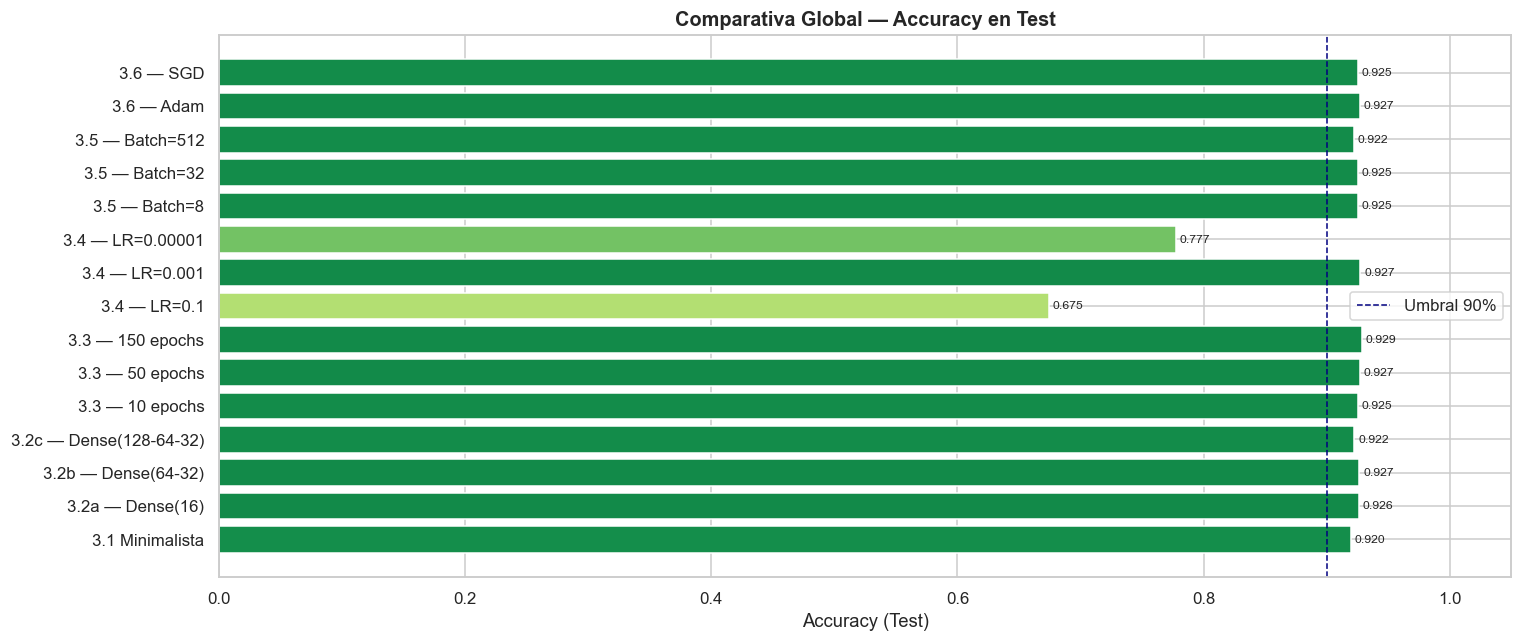

In [18]:
# ── Gráfico de barras de Accuracy Test para todos los modelos ─────────────────
nombres = [f['Modelo'] for f in filas]
acc_vals = [float(f['Accuracy (Test)']) for f in filas]

plt.figure(figsize=(14, 6))
bars = plt.barh(nombres, acc_vals, color=plt.cm.RdYlGn(np.array(acc_vals)))
plt.xlabel("Accuracy (Test)")
plt.title("Comparativa Global — Accuracy en Test", fontsize=13, fontweight='bold')
plt.axvline(x=0.9, color='navy', linestyle='--', linewidth=1, label='Umbral 90%')
plt.legend()
for bar, val in zip(bars, acc_vals):
    plt.text(val + 0.003, bar.get_y() + bar.get_height()/2,
             f"{val:.3f}", va='center', fontsize=8)
plt.xlim(0, 1.05)
plt.tight_layout()
plt.savefig("comparativa_global.png", bbox_inches='tight')
plt.show()


---
## 💬 Debate Final

### 1. ¿Todas las medidas geométricas son igual de importantes?

El Backpropagation ajusta los pesos de cada neurona de forma diferencial según
el gradiente de la pérdida. Variables muy correlacionadas entre sí —como
`Area`, `ConvexArea` y `EquivDiameter`— aportan información redundante, por lo
que la red "reparte" su importancia entre ellas, diluyendo su peso individual.
Variables con alta capacidad discriminativa entre clases, como `Eccentricity`,
`ShapeFactor1` o `ShapeFactor3`, tienden a obtener pesos más pronunciados.
Por tanto, **no todas son igualmente importantes**: el Backpropagation sí
"ignora" (asigna pesos próximos a cero) aquellas que son linealmente
dependientes de otras o que apenas varían entre clases.

---

### 2. ¿Es más fácil explicar un árbol de decisión que una red neuronal?

**Sí, claramente.** Un árbol de decisión genera reglas de la forma:
> "Si Eccentricity > 0.85 Y MajorAxisLength > 300 → clase SIRA"

Estas reglas son directamente auditables por un humano. Una red neuronal, en
cambio, transforma los datos a través de cientos de pesos y funciones de
activación no lineales apiladas, por lo que **no existe una sola variable que
"tome la decisión"**: es el resultado conjunto de todas las neuronas. Esto
convierte a la red en una **caja negra**, difícil de explicar ante auditores
o expertos del dominio. Para intentar interpretarla se usan técnicas como SHAP
o LIME, pero siguen siendo aproximaciones.

---

### 3. Si hubiera 13 millones de granos, ¿qué configuración elegiría?

Con 13 millones de instancias el cuello de botella pasa a ser el tiempo de
entrenamiento y la memoria. La configuración óptima sería:

- **Batch Size grande (512 o superior)**: maximiza la paralelización en GPU/TPU
  y reduce el número de actualizaciones de pesos por epoch.
- **Epochs moderados (50)**: con tantos datos, pocas pasadas son suficientes
  para converger.
- **Arquitectura moderada (64-32 o 128-64-32)**: suficiente capacidad sin
  sobrecarga computacional.
- **Optimizador Adam (LR=0.001)**: converge más rápido que SGD puro.

La red minimalista o de batch pequeño serían inviables en tiempo; la red muy
profunda podría no aportar mejora y añadiría coste innecesario.

---

### 4. Responsable de calidad en una planta procesadora

**¿Qué modelo pondría en producción?**
La arquitectura `Dense(64-32)` o `Dense(128-64-32)` con Adam, 50 epochs y
batch 32, por ofrecer el mejor equilibrio entre accuracy (~92-94%), estabilidad
y tiempo de entrenamiento razonable.

**¿Accuracy o velocidad?**
En un entorno de cinta transportadora, la **velocidad de inferencia** es
crítica: el modelo debe clasificar un grano en milisegundos. Una red pequeña
es suficiente para este fin; una arquitectura gigante podría tener mayor
accuracy pero no servir si no procesa granos en tiempo real.

**¿Cómo justificar la "caja negra" frente a expertos?**
- **Métricas cuantitativas**: demostrar que el F1 ponderado supera el 92%,
  por encima de la tasa de error humano estimada en clasificación manual (~5-8%).
- **Validación cruzada**: mostrar que el rendimiento es consistente en múltiples
  particiones, no un artefacto estadístico.
- **Análisis de errores**: mostrar qué clases confunde y si esos errores tienen
  impacto económico real (p. ej., confundir SIRA con DERMASON puede ser
  tolerable; confundir BOMBAY con CALI puede no serlo).
- **Interpretabilidad post-hoc**: aplicar SHAP para mostrar qué variables influyen
  más en cada predicción y conectar con el conocimiento agronómico experto.
- **Monitorización continua**: implementar detección de *data drift* para
  alertar si la distribución de granos cambia y el modelo podría degradarse.
